In [8]:
# =========================================================
# NOTEBOOK: 08_delay_prediction.ipynb
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler

import shap
import joblib
import os

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [9]:

# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [10]:
# =========================================================
# STEP 3 — DATASET OVERVIEW
# =========================================================

print("\nDataset Shape:")
print(master_df.shape)

print("\nDataset Sample:\n")
print(master_df.head())


Dataset Shape:
(2530433, 87)

Dataset Sample:

                               order_id                           customer_id  \
0  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
1  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
2  720fd9e9-cdeb-4dec-a187-f71586eb085a  1e2e2881-a0eb-4cb0-829f-a566e810d05f   
3  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   
4  c0142972-63fa-4af2-8070-f583ab769847  380b7418-308c-4bf7-b2bd-3ee446cb9ea6   

  order_status order_purchase_timestamp    order_approved_at  \
0     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
1     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
2     canceled      2025-12-27 07:07:20  2025-12-27 08:33:20   
3    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   
4    delivered      2019-06-07 19:30:44  2019-06-08 05:08:44   

  order_delivered_carrier_date order_delivered_customer_date  \
0               

In [11]:
# =========================================================
# STEP 4 — CUSTOMER LEVEL DATASET
# =========================================================

customer_df = (master_df
               .sort_values('order_purchase_timestamp')
               .groupby('customer_unique_id')
               .last()
               .reset_index())

print("\nCustomer-Level Dataset Shape:")
print(customer_df.shape)


Customer-Level Dataset Shape:
(279199, 87)


In [12]:
# =========================================================
# STEP 5 — CREATE DELAY TARGET
# =========================================================

customer_df['delivery_delay_target'] = np.where(
    customer_df['delivery_delay_days'] > 0,
    customer_df['delivery_delay_days'],
    0
)

print("\nDelay Target Created")


Delay Target Created



Delay Statistics:

count    279199.000000
mean          0.061198
std           0.304914
min           0.000000
25%           0.036951
50%           0.036951
75%           0.036951
max           9.350349
Name: delivery_delay_target, dtype: float64


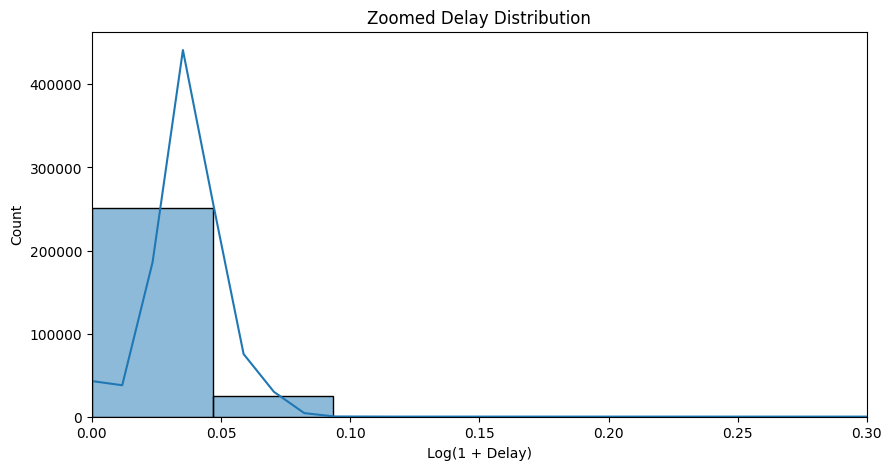

In [24]:
# =========================================================
# STEP 6 — TARGET DISTRIBUTION
# =========================================================

print("\nDelay Statistics:\n")

print(customer_df['delivery_delay_target'].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(customer_df['delivery_delay_target']),
    bins=50,
    kde=True
)

plt.xlim(0, 0.3)

plt.title("Zoomed Delay Distribution")

plt.xlabel("Log(1 + Delay)")

plt.show()

In [33]:
# =========================================================
# STEP 7 — REMOVE LEAKAGE FEATURES
# =========================================================

leakage_cols = [

    'delivery_delay_target',

    'delivery_delay_days',
    'delivery_duration_days',
    'avg_delivery_delay',
    'product_avg_delay',

    'customer_id',
    'customer_unique_id',
    'order_id',
    'product_id',
    'seller_id',
    'review_id',

    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',

    'review_creation_date',
    'review_answer_timestamp',

    'Recency',
    'churn'
]

duplicate_cols = [col for col in customer_df.columns
                  if col.endswith('1')]

X = customer_df.drop(
    columns=leakage_cols + duplicate_cols,
    errors='ignore'
)

y = customer_df['delivery_delay_target']

print("\nFeature Matrix Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


Feature Matrix Shape:
(279199, 61)

Target Shape:
(279199,)


In [34]:
# =========================================================
# STEP 8 — HANDLE CATEGORICAL FEATURES
# =========================================================

cat_cols = X.select_dtypes(include='object').columns

safe_cat_cols = [col for col in cat_cols
                 if X[col].nunique() <= 20]

print("\nSafe Categorical Columns:")
print(safe_cat_cols)

X = pd.get_dummies(
    X,
    columns=safe_cat_cols,
    drop_first=True
)

X = X.select_dtypes(exclude='object')

X.columns = (X.columns
             .str.replace(' ', '_')
             .str.replace('[^A-Za-z0-9_]', '', regex=True))

print("\nEncoded Feature Shape:")
print(X.shape)


Safe Categorical Columns:
['order_status', 'customer_city', 'customer_state', 'seller_contact_gender', 'seller_city', 'seller_state']

Encoded Feature Shape:
(279199, 91)


In [35]:
# =========================================================
# STEP 9 — CORRELATION CHECK
# =========================================================

corr_check = X.corrwith(y).sort_values(ascending=False)

print("\nTop Correlations:\n")
print(corr_check.head(20))


Top Correlations:

product_avg_review        0.005206
customer_city_New_York    0.003955
customer_state_NY         0.003955
purchase_weekend          0.003245
product_weight_g          0.003017
seller_city_Houston       0.002525
seller_state_TX           0.002525
seller_avg_delay          0.002514
product_height_cm         0.002261
customer_city_Miami       0.001856
customer_state_FL         0.001856
seller_state_GA           0.001679
product_category_name     0.001675
product_length_cm         0.001504
customer_state_CO         0.001430
customer_city_Denver      0.001430
seller_state_WA           0.001148
seller_city_Seattle       0.001148
order_item_id             0.001102
payment_bank_transfer     0.001029
dtype: float64


In [36]:
# =========================================================
# STEP 10 — TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain Test Split Completed")

print(f"X_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")



Train Test Split Completed
X_train Shape : (223359, 91)
X_test Shape  : (55840, 91)


In [37]:
# =========================================================
# STEP 11 — FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed")


Feature Scaling Completed


In [38]:
# =========================================================
# STEP 12 — LINEAR REGRESSION
# =========================================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

print("\nLinear Regression Trained")


Linear Regression Trained


In [ ]:
# =========================================================
# STEP 13 — DECISION TREE
# =========================================================

dt_model = DecisionTreeRegressor( max_depth=10, random_state=42)

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree Trained")

Decision Tree Trained


In [41]:
# =========================================================
# STEP 14 — RANDOM FOREST
# =========================================================

rf_model = RandomForestRegressor( n_estimators=200, 
                                  max_depth=15, 
                                  random_state=42, 
                                  n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest Trained")

Random Forest Trained


In [42]:
# =========================================================
# STEP 15 — XGBOOST
# =========================================================

xgb_model = XGBRegressor( n_estimators=200,
                         learning_rate=0.1,
                         max_depth=8,
                         random_state=42,
                         n_jobs=-1 )

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Trained")

XGBoost Trained


In [43]:
# =========================================================
# STEP 16 — LIGHTGBM
# =========================================================

lgbm_model = LGBMRegressor( n_estimators=200,
                            learning_rate=0.1,
                            max_depth=8,
                            random_state=42,
                            n_jobs=-1 )

lgbm_model.fit(X_train, y_train)

lgbm_preds = lgbm_model.predict(X_test)

print("LightGBM Trained")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5763
[LightGBM] [Info] Number of data points in the train set: 223359, number of used features: 90
[LightGBM] [Info] Start training from score 0.061116
LightGBM Trained


In [44]:
# =========================================================
# STEP 17 — CATBOOST
# =========================================================

cat_model = CatBoostRegressor( iterations=200, 
                               learning_rate=0.1, 
                               depth=8, 
                               random_state=42, 
                               verbose=0 )

cat_model.fit(X_train, y_train)

cat_preds = cat_model.predict(X_test)

print("CatBoost Trained")

CatBoost Trained


In [45]:
# =========================================================
# STEP 18 — EVALUATION FUNCTION
# =========================================================

def evaluate_regression_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print("\n===================================================")
    print(f"{model_name} PERFORMANCE")
    print("===================================================")

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")


In [46]:
# =========================================================
# STEP 19 — MODEL EVALUATION
# =========================================================

evaluate_regression_model(y_test, lr_preds, "Linear Regression")

evaluate_regression_model(y_test, dt_preds, "Decision Tree")

evaluate_regression_model(y_test, rf_preds, "Random Forest")

evaluate_regression_model(y_test, xgb_preds, "XGBoost")

evaluate_regression_model(y_test, lgbm_preds, "LightGBM")

evaluate_regression_model(y_test, cat_preds, "CatBoost")


Linear Regression PERFORMANCE
MAE  : 0.08
RMSE : 0.29
R2   : 0.0933

Decision Tree PERFORMANCE
MAE  : 0.02
RMSE : 0.21
R2   : 0.5178

Random Forest PERFORMANCE
MAE  : 0.02
RMSE : 0.17
R2   : 0.6752

XGBoost PERFORMANCE
MAE  : 0.02
RMSE : 0.18
R2   : 0.6454

LightGBM PERFORMANCE
MAE  : 0.02
RMSE : 0.18
R2   : 0.6626

CatBoost PERFORMANCE
MAE  : 0.02
RMSE : 0.17
R2   : 0.6772


In [47]:
# =========================================================
# STEP 20 — CROSS VALIDATION
# =========================================================

print("\n================ CROSS VALIDATION ================\n")

cv_scores = cross_val_score( cat_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print("CatBoost CV Scores:")
print(cv_scores)

print(f"\nAverage CV Score: {cv_scores.mean():.4f}")


================ CROSS VALIDATION ================

CatBoost CV Scores:
[0.59614854 0.60223651 0.65201044 0.62710729 0.69742612]

Average CV Score: 0.6350


In [48]:
# =========================================================
# STEP 21 — HYPERPARAMETER TUNING
# =========================================================

print("\n================ CATBOOST TUNING ================\n")

param_grid = {'iterations': [100, 200],
              'learning_rate': [0.05, 0.1],
              'depth': [5, 8] }

grid_search = GridSearchCV( estimator=CatBoostRegressor( random_state=42,
                                                         verbose=0,
                                                         thread_count=-1),
                            param_grid=param_grid,
                            scoring='r2',
                            cv=3,
                            n_jobs=-1,
                            verbose=1 )

grid_search.fit(X_train, y_train)

best_cat_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)


================ CATBOOST TUNING ================

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'depth': 5, 'iterations': 100, 'learning_rate': 0.05}

Best CV Score:
0.6451748157507294


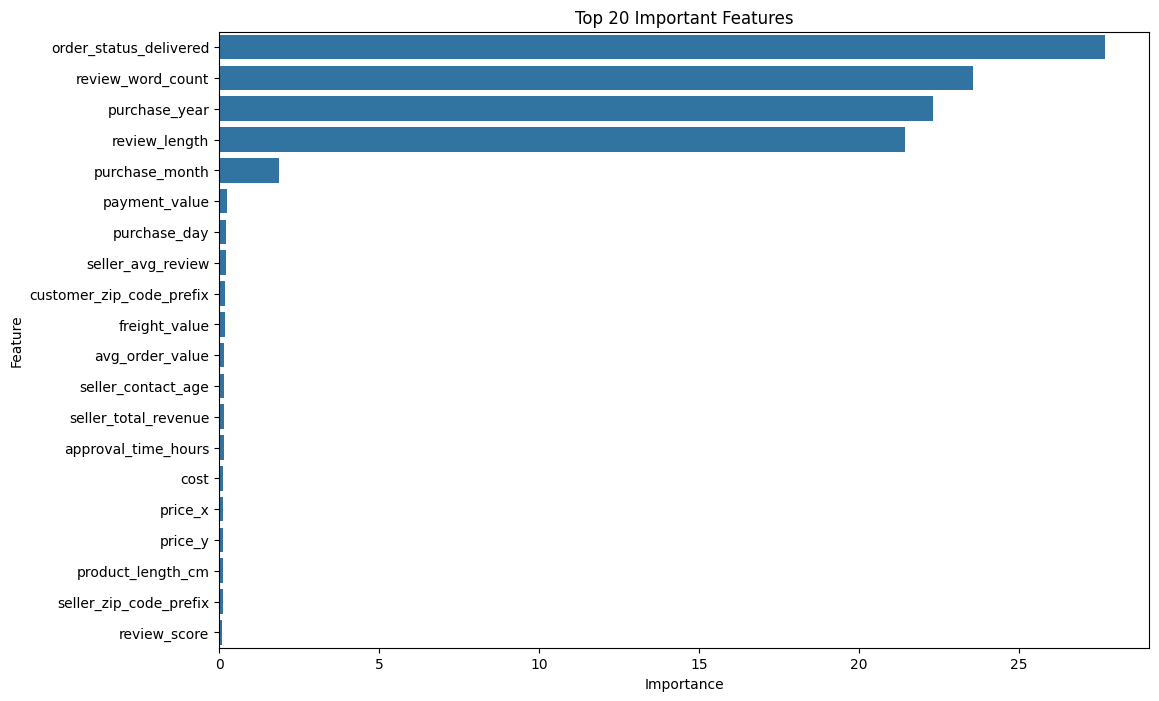

In [50]:
# =========================================================
# STEP 22 — FEATURE IMPORTANCE
# =========================================================

feature_importance = pd.DataFrame({ 'Feature': X.columns,
                                    'Importance': best_cat_model.feature_importances_ })

feature_importance = (feature_importance
                      .sort_values(by='Importance', ascending=False)
                      .head(20))

plt.figure(figsize=(12,8))

sns.barplot( x='Importance',
             y='Feature',
             data=feature_importance )

plt.title("Top 20 Important Features")

plt.show()



================ SHAP ANALYSIS ================



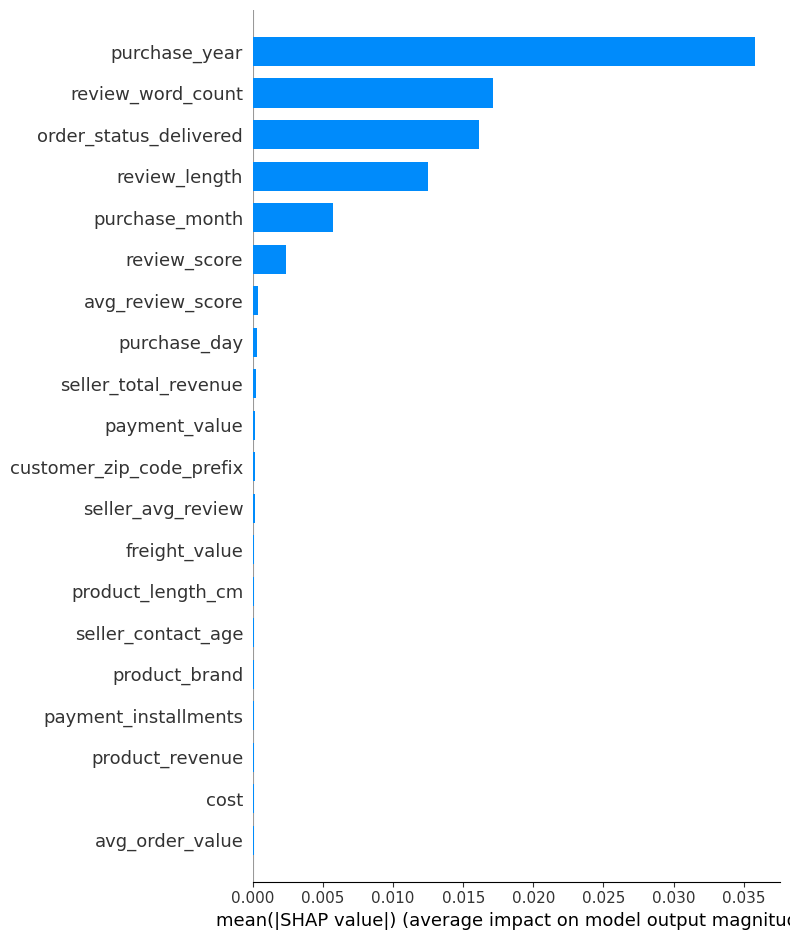

In [52]:
# =========================================================
# STEP 23 — SHAP EXPLAINABILITY
# =========================================================

print("\n================ SHAP ANALYSIS ================\n")

sample_X = X_test.sample( 2000, random_state=42 )

explainer = shap.TreeExplainer(best_cat_model)

shap_values = explainer.shap_values(sample_X)

shap.summary_plot( shap_values, sample_X, plot_type='bar')

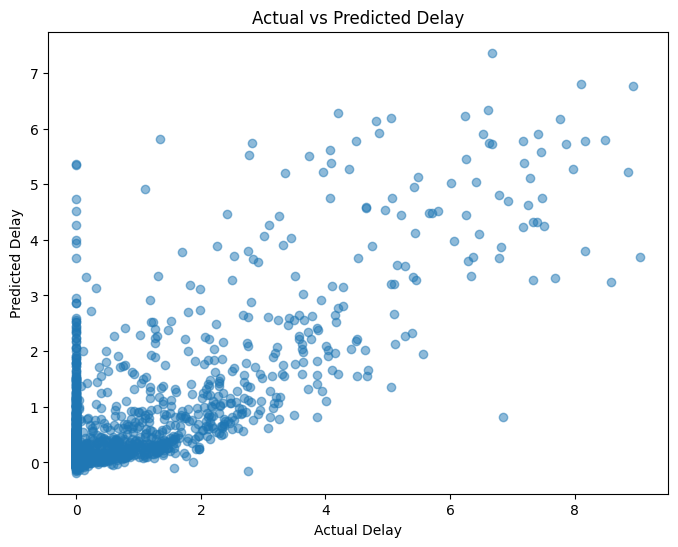

In [53]:
# =========================================================
# STEP 24 — ACTUAL VS PREDICTED
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter( y_test, lgbm_preds, alpha=0.5)

plt.xlabel("Actual Delay")

plt.ylabel("Predicted Delay")

plt.title("Actual vs Predicted Delay")

plt.show()

In [2]:
# =========================================================
# STEP 25 — SAVE MODEL
# =========================================================

joblib.dump(
    best_cat_model,
    MODELS_DIR / "delay_model.pkl"
)

print("Delay Model Saved Successfully")

NameError: name 'joblib' is not defined

In [1]:
# =========================================================
# STEP 26 — SAVE FEATURE COLUMNS
# =========================================================

joblib.dump(
    X.columns.tolist(),
    MODELS_DIR / "delay_features.pkl"
)

print("Delay Feature Columns Saved Successfully")

NameError: name 'joblib' is not defined

In [56]:

# =========================================================
# STEP 27 — BUSINESS INSIGHTS
# =========================================================

print("\n===================================================")
print("BUSINESS INSIGHTS")
print("===================================================")

print("""

1. Built delivery delay prediction pipeline.

2. Compared:
   - Linear Regression
   - Decision Tree
   - Random Forest
   - XGBoost
   - LightGBM
   - CatBoost

3. Evaluated models using:
   - MAE
   - RMSE
   - R2 Score

4. Performed:
   - Cross Validation
   - Hyperparameter Tuning
   - SHAP Explainability

5. Identified important delay-driving features.

6. Created production-ready saved model artifacts.

7. Model can support:
   - Delivery optimization
   - Logistics planning
   - Delay risk prediction
   - Customer satisfaction improvement

""")


BUSINESS INSIGHTS


1. Built delivery delay prediction pipeline.

2. Compared:
   - Linear Regression
   - Decision Tree
   - Random Forest
   - XGBoost
   - LightGBM
   - CatBoost

3. Evaluated models using:
   - MAE
   - RMSE
   - R2 Score

4. Performed:
   - Cross Validation
   - Hyperparameter Tuning
   - SHAP Explainability

5. Identified important delay-driving features.

6. Created production-ready saved model artifacts.

7. Model can support:
   - Delivery optimization
   - Logistics planning
   - Delay risk prediction
   - Customer satisfaction improvement




In [57]:

# =========================================================
# STEP 28 — NOTEBOOK COMPLETION
# =========================================================

print("\n===================================================")
print("08_delay_prediction.ipynb COMPLETED SUCCESSFULLY")
print("===================================================")


08_delay_prediction.ipynb COMPLETED SUCCESSFULLY
